3.


---


In [1]:
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
# os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_USE_CUDNN_AUTOTUNE"] = "0"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

# "1" si PB.
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

# Désactive le XLA auto-jit
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

In [2]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)
tf.config.experimental.enable_op_determinism()

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=9000)]
    )

print("TF:", tf.__version__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF: 2.20.0


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import (
    PROJECT_ROOT,
    CITYSCAPES_DIR,
    OUT_DIR,
    EXP_DIR,
    DATA_DIR,
    CSV_SPLIT,
    resolve_split_csv,
    ensure_dirs,
)

ensure_dirs()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CITYSCAPES_DIR:", CITYSCAPES_DIR)
print("OUT_DIR:", OUT_DIR)
print("EXP_DIR:", EXP_DIR)
print("CSV_SPLIT (raw):", CSV_SPLIT)
print("CSV_SPLIT (resolved):", resolve_split_csv())

PROJECT_ROOT: /home/ui/PROJ8
CITYSCAPES_DIR: /home/ui/PROJ8/data/raw/cityscapes
OUT_DIR: /home/ui/PROJ8/out
EXP_DIR: /home/ui/PROJ8/out/experiments
CSV_SPLIT (raw): /home/ui/PROJ8/out/cityscapes_split_testXtrainXval.csv
CSV_SPLIT (resolved): /home/ui/PROJ8/out/cityscapes_split_testXtrainXval.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from scripts.augmentations import make_train_aug
from scripts.datagen import CityscapesSequence
from scripts.preprocessing import (
    remap_to_groups,
    colorize_groups,
    overlay,
    IGNORE_LABEL,
    N_CLASSES,
    CATEGORY_NAMES,
)
from scripts.losses_metrics import MeanIoUArgmax, dice_loss_sparse
from scripts.training import run_unet_scratch, reset_between_runs

In [ ]:
csv_path = resolve_split_csv()
df_idx = pd.read_csv(csv_path)

df_idx["image_path"] = df_idx["image_rel"].apply(lambda p: str(CITYSCAPES_DIR / p))
df_idx["mask_path"] = df_idx["mask_rel"].apply(lambda p: str(CITYSCAPES_DIR / p))

print(df_idx["split_final"].value_counts())

train_df = df_idx[df_idx["split_final"] == "train"].copy()
val_df = df_idx[df_idx["split_final"] == "val"].copy()
test_df = df_idx[df_idx["split_final"] == "test"].copy()
print(len(train_df), len(val_df), len(test_df))

split_final
train    2380
test      595
val       500
Name: count, dtype: int64
2380 500 595


/home/ui/PROJ8/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ8/.venv2/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


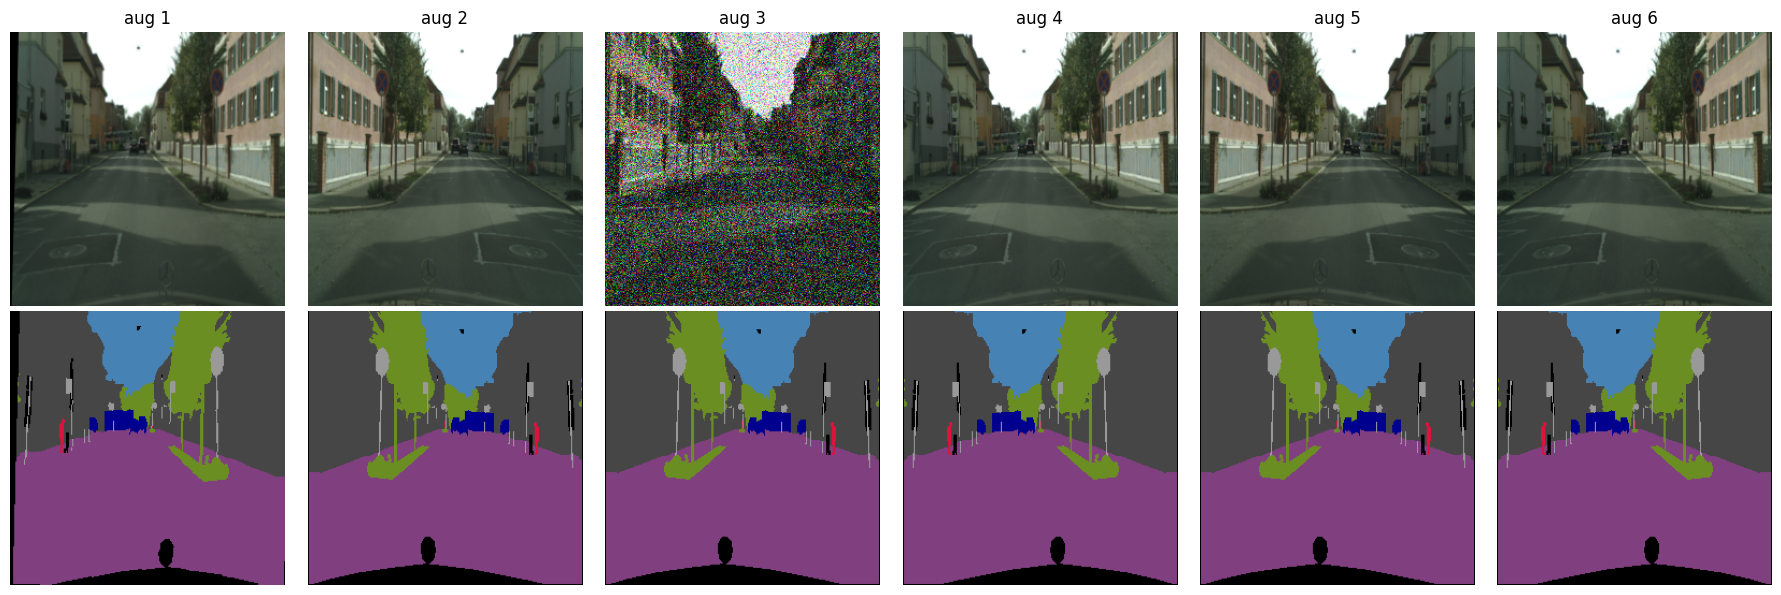

In [6]:
import albumentations as A

aug = make_train_aug()

row = train_df.sample(1, random_state=42).iloc[0]
img = Image.open(row["image_path"]).convert("RGB")
mask = remap_to_groups(Image.open(row["mask_path"]))

img = img.resize((256, 256), Image.BILINEAR)
mask = mask.resize((256, 256), Image.NEAREST)

img_np = np.array(img)
mask_np = np.array(mask, dtype=np.uint8)

N = 6
fig, ax = plt.subplots(2, N, figsize=(3 * N, 6))
for i in range(N):
    out = aug(image=img_np, mask=mask_np)
    img_i = Image.fromarray(out["image"])
    m_i = Image.fromarray(out["mask"], mode="L")
    ax[0, i].imshow(img_i)
    ax[0, i].axis("off")
    ax[0, i].set_title(f"aug {i+1}")
    ax[1, i].imshow(colorize_groups(m_i))
    ax[1, i].axis("off")
plt.tight_layout()
plt.show()

In [7]:
import json
import tensorflow as tf


def save_history_json(hist_dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(hist_dict, f, indent=2)


def save_summary_json(summary_dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(summary_dict, f, indent=2)


def plot_curves(hist, out_png: Path):
    plt.figure(figsize=(10, 4))
    if "loss" in hist:
        plt.plot(hist["loss"], label="loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

    plt.figure(figsize=(10, 4))
    key_train = (
        "mIoU" if "mIoU" in hist else ("mean_iou" if "mean_iou" in hist else None)
    )
    key_val = (
        "val_mIoU"
        if "val_mIoU" in hist
        else ("val_mean_iou" if "val_mean_iou" in hist else None)
    )
    if key_train:
        plt.plot(hist[key_train], label=key_train)
    if key_val:
        plt.plot(hist[key_val], label=key_val)
    plt.legend()
    plt.title("Mean IoU")
    plt.xlabel("epoch")
    plt.ylabel("IoU")
    plt.tight_layout()
    plt.savefig(
        out_png.with_name(out_png.stem.replace("loss", "miou") + ".png"), dpi=160
    )
    plt.show()


def visualize_predictions(
    best_model_path: Path, size_hw=(256, 256), n=4, out_png: Path | None = None
):
    custom_objects = {
        "MeanIoUArgmax": MeanIoUArgmax,
        "dice_loss_sparse": dice_loss_sparse,
    }
    model = tf.keras.models.load_model(
        best_model_path, custom_objects=custom_objects, compile=False
    )

    seq = CityscapesSequence(
        test_df,
        base_dir=DATA_DIR,
        batch_size=n,
        size_hw=size_hw,
        augment=None,
        shuffle=False,
    )
    X, y = seq[0]
    pred = model.predict(X, verbose=0)
    pred_cls = np.argmax(pred, axis=-1).astype(np.uint8)

    fig, ax = plt.subplots(n, 4, figsize=(18, 4 * n))
    for i in range(n):
        img = Image.fromarray((X[i] * 255).astype(np.uint8))
        gt = Image.fromarray(y[i, ..., 0].astype(np.uint8), mode="L")
        pr = Image.fromarray(pred_cls[i].astype(np.uint8), mode="L")

        gt_col = colorize_groups(gt)
        pr_col = colorize_groups(pr)

        ax[i, 0].imshow(img)
        ax[i, 0].set_title("RGB")
        ax[i, 0].axis("off")
        ax[i, 1].imshow(gt_col)
        ax[i, 1].set_title("GT")
        ax[i, 1].axis("off")
        ax[i, 2].imshow(pr_col)
        ax[i, 2].set_title("Pred")
        ax[i, 2].axis("off")
        ax[i, 3].imshow(overlay(img, pr_col, 0.45))
        ax[i, 3].set_title("Overlay")
        ax[i, 3].axis("off")
    plt.tight_layout()

    if out_png is not None:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_png, dpi=160)
    plt.show()

---


In [8]:
from scripts.models import unet_vgg16
from scripts.training import compile_model, reset_between_runs

In [9]:
import tensorflow as tf
from tensorflow.keras import callbacks
import time


def run_vgg16(
    size_hw=(256, 256),
    batch=4,
    epochs=40,
    aug=True,
    loss_name="ce_dice",
    patience=8,
    trainable=False,
):
    reset_between_runs(42)

    train_aug = make_train_aug() if aug else None
    train_seq = CityscapesSequence(
        train_df,
        base_dir=DATA_DIR,
        batch_size=batch,
        size_hw=size_hw,
        augment=train_aug,
        shuffle=True,
        seed=42,
        aug_repeats=1,
    )
    val_seq = CityscapesSequence(
        val_df,
        base_dir=DATA_DIR,
        batch_size=batch,
        size_hw=size_hw,
        augment=None,
        shuffle=False,
        seed=42,
        aug_repeats=1,
    )
    test_seq = CityscapesSequence(
        test_df,
        base_dir=DATA_DIR,
        batch_size=batch,
        size_hw=size_hw,
        augment=None,
        shuffle=False,
        seed=42,
        aug_repeats=1,
    )

    model = unet_vgg16(
        input_shape=(size_hw[0], size_hw[1], 3),
        n_classes=N_CLASSES,
        trainable=trainable,
    )
    model = compile_model(model, loss_name=loss_name, lr=1e-3)

    run_name = f"VGG16_{'FT' if trainable else 'FROZEN'}_{size_hw[0]}x{size_hw[1]}_b{batch}_aug{int(aug)}_{loss_name}"
    run_folder = EXP_DIR / run_name
    run_folder.mkdir(parents=True, exist_ok=True)
    best_path = run_folder / "best.keras"

    cb = [
        callbacks.ModelCheckpoint(
            str(best_path), monitor="val_mIoU", mode="max", save_best_only=True
        ),
        callbacks.EarlyStopping(
            monitor="val_mIoU", mode="max", patience=patience, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_mIoU", mode="max", patience=3, factor=0.5, min_lr=1e-5
        ),
    ]

    t0 = time.time()
    hist = model.fit(
        train_seq, validation_data=val_seq, epochs=epochs, callbacks=cb, verbose=1
    )
    t_train = time.time() - t0

    val_res = model.evaluate(val_seq, verbose=0)
    test_res = model.evaluate(test_seq, verbose=0)

    res = dict(
        run_name=run_name,
        best_path=str(best_path),
        train_time_sec=float(t_train),
        val_loss=float(val_res[0]),
        val_mIoU=float(val_res[1]),
        test_loss=float(test_res[0]),
        test_mIoU=float(test_res[1]),
        history=hist.history,
    )

    save_summary_json(
        {k: v for k, v in res.items() if k != "history"}, run_folder / "summary.json"
    )
    save_history_json(res["history"], run_folder / "history.json")
    plot_curves(res["history"], run_folder / "loss.png")
    visualize_predictions(
        best_path, size_hw=size_hw, n=6, out_png=run_folder / "pred_grid.png"
    )

    return res

I0000 00:00:1770004412.902930 1759806 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9000 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


Epoch 1/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 314s 516ms/step - loss: 0.8078 - mIoU: 0.5185 - val_loss: 0.6446 - val_mIoU: 0.5989 - learning_rate: 0.0010
Epoch 2/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 301s 505ms/step - loss: 0.6684 - mIoU: 0.5817 - val_loss: 0.5753 - val_mIoU: 0.6338 - learning_rate: 0.0010
Epoch 3/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 303s 509ms/step - loss: 0.6275 - mIoU: 0.6031 - val_loss: 0.5760 - val_mIoU: 0.6251 - learning_rate: 0.0010
Epoch 4/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 301s 505ms/step - loss: 0.5936 - mIoU: 0.6203 - val_loss: 0.5568 - val_mIoU: 0.6460 - learning_rate: 0.0010
Epoch 5/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 304s 510ms/step - loss: 0.5752 - mIoU: 0.6286 - val_loss: 0.5180 - val_mIoU: 0.6607 - learning_rate: 0.0010
Epoch 6/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 304s 510ms/step - loss: 0.5530 - mIoU: 0.6395 - val_loss: 0.5002 - val_mIoU: 0.6730 - learning_rate: 0.0010
Epoch 7/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 300s 505ms/step - loss: 0.5519 - mIoU: 0.6423 - val_loss: 0.4939 - val_m

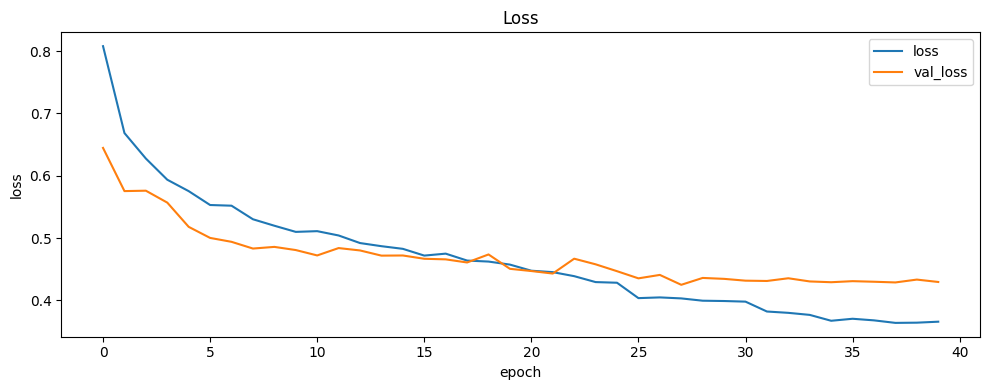

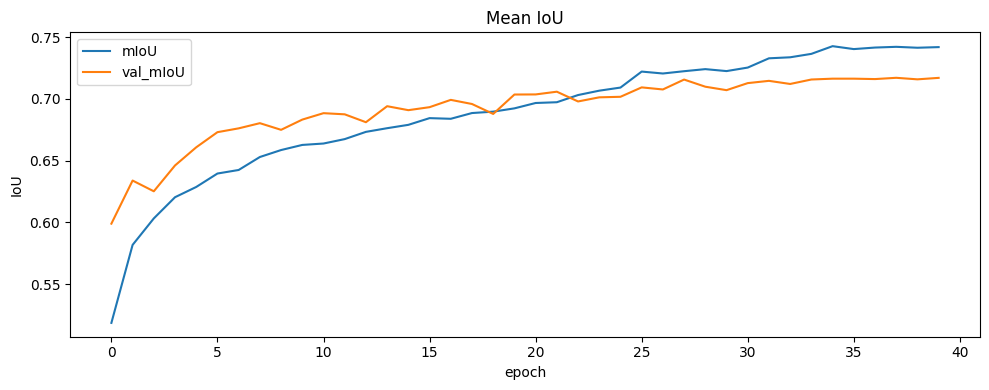

2026-02-02 08:16:59.040404: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


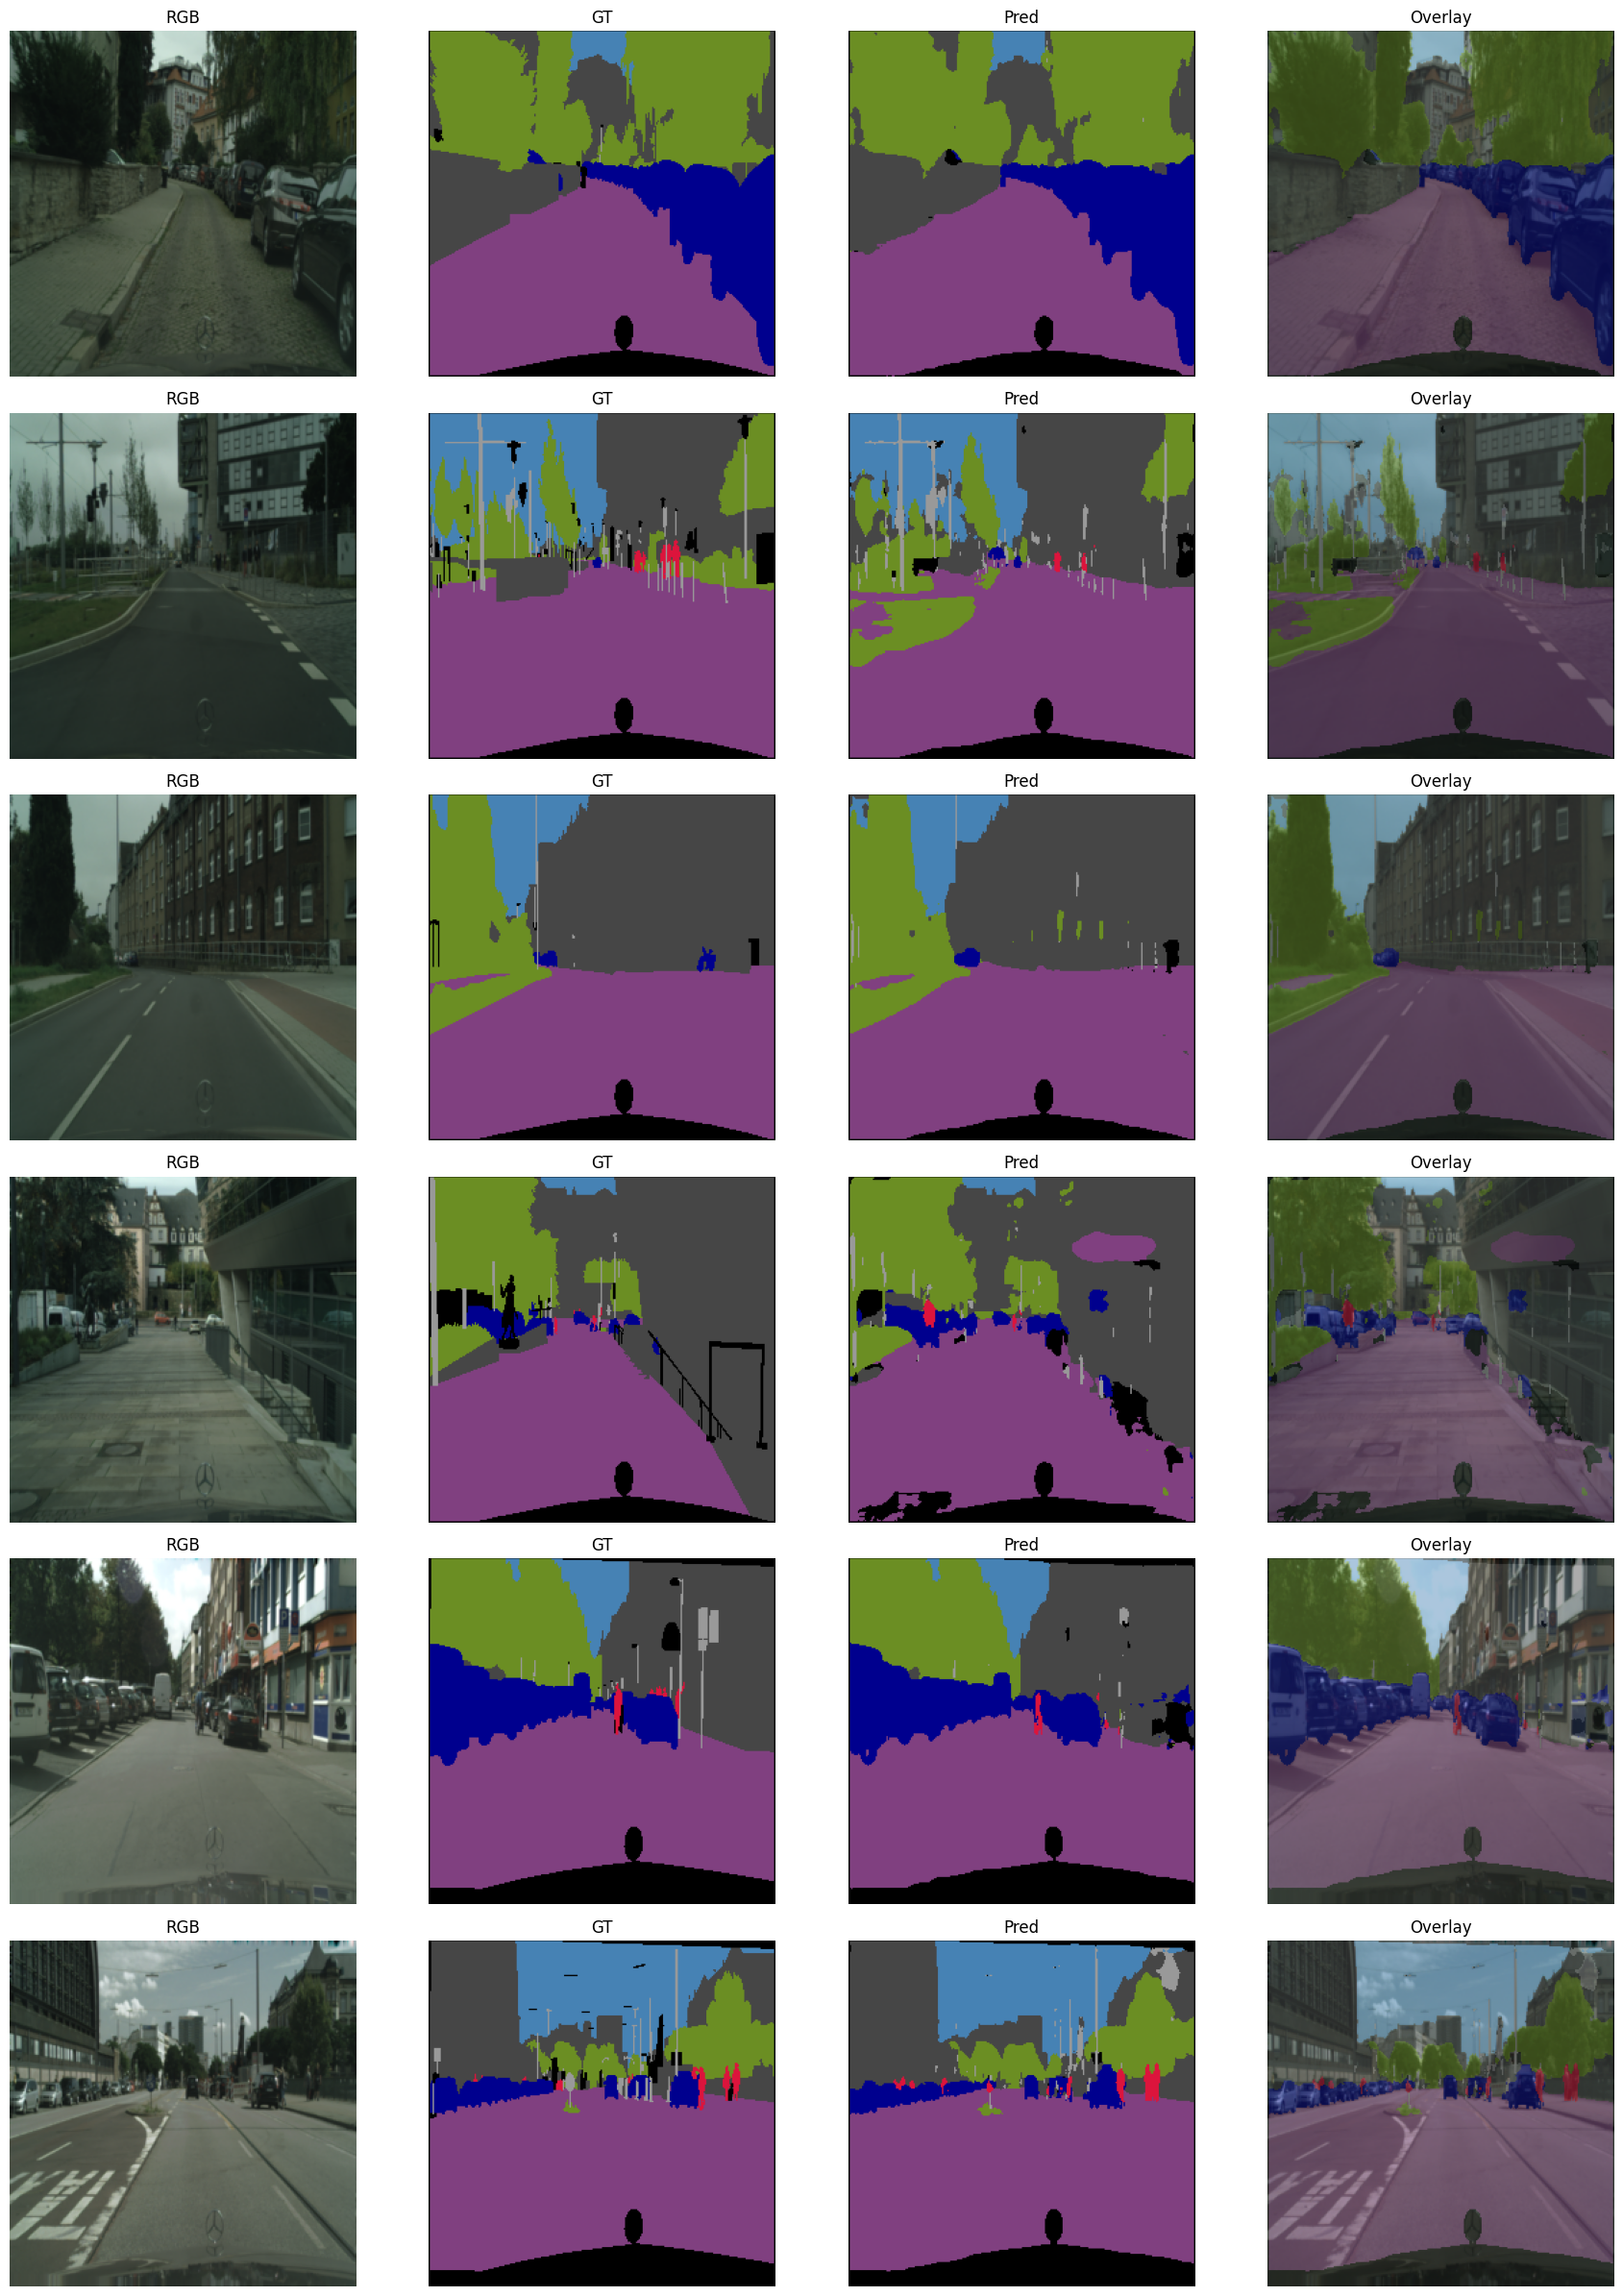

Epoch 1/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 340s 561ms/step - loss: 0.9148 - mIoU: 0.4629 - val_loss: 0.9957 - val_mIoU: 0.4342 - learning_rate: 0.0010
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 332s 559ms/step - loss: 0.7366 - mIoU: 0.5401 - val_loss: 0.7265 - val_mIoU: 0.5548 - learning_rate: 0.0010
Epoch 3/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 337s 566ms/step - loss: 0.6704 - mIoU: 0.5742 - val_loss: 0.6493 - val_mIoU: 0.5960 - learning_rate: 0.0010
Epoch 4/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 332s 558ms/step - loss: 0.6434 - mIoU: 0.5872 - val_loss: 0.6213 - val_mIoU: 0.6094 - learning_rate: 0.0010
Epoch 5/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 333s 559ms/step - loss: 0.6048 - mIoU: 0.6071 - val_loss: 0.5530 - val_mIoU: 0.6479 - learning_rate: 0.0010
Epoch 6/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 336s 565ms/step - loss: 0.5805 - mIoU: 0.6212 - val_loss: 0.6553 - val_mIoU: 0.6115 - learning_rate: 0.0010
Epoch 7/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 332s 559ms/step - loss: 0.5540 - mIoU: 0.6337 - val_loss: 0.5310 - val_m

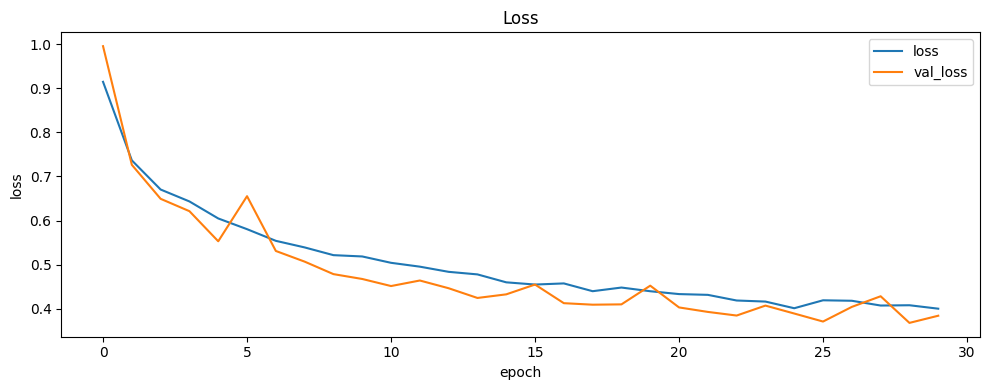

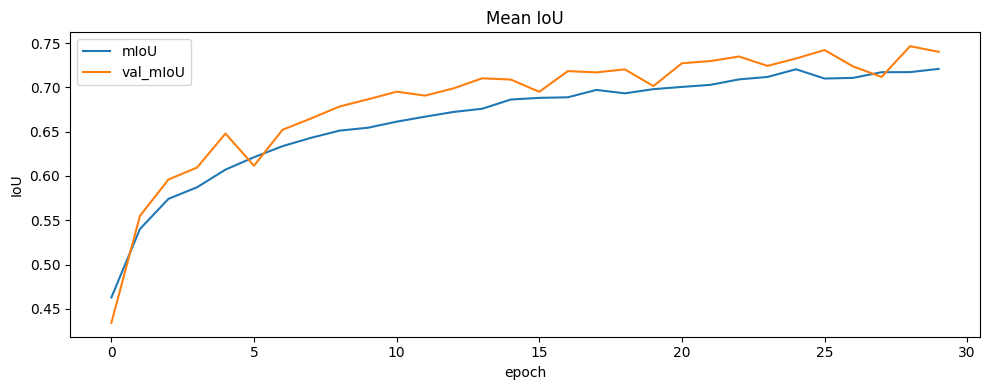

2026-02-02 11:05:38.510406: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


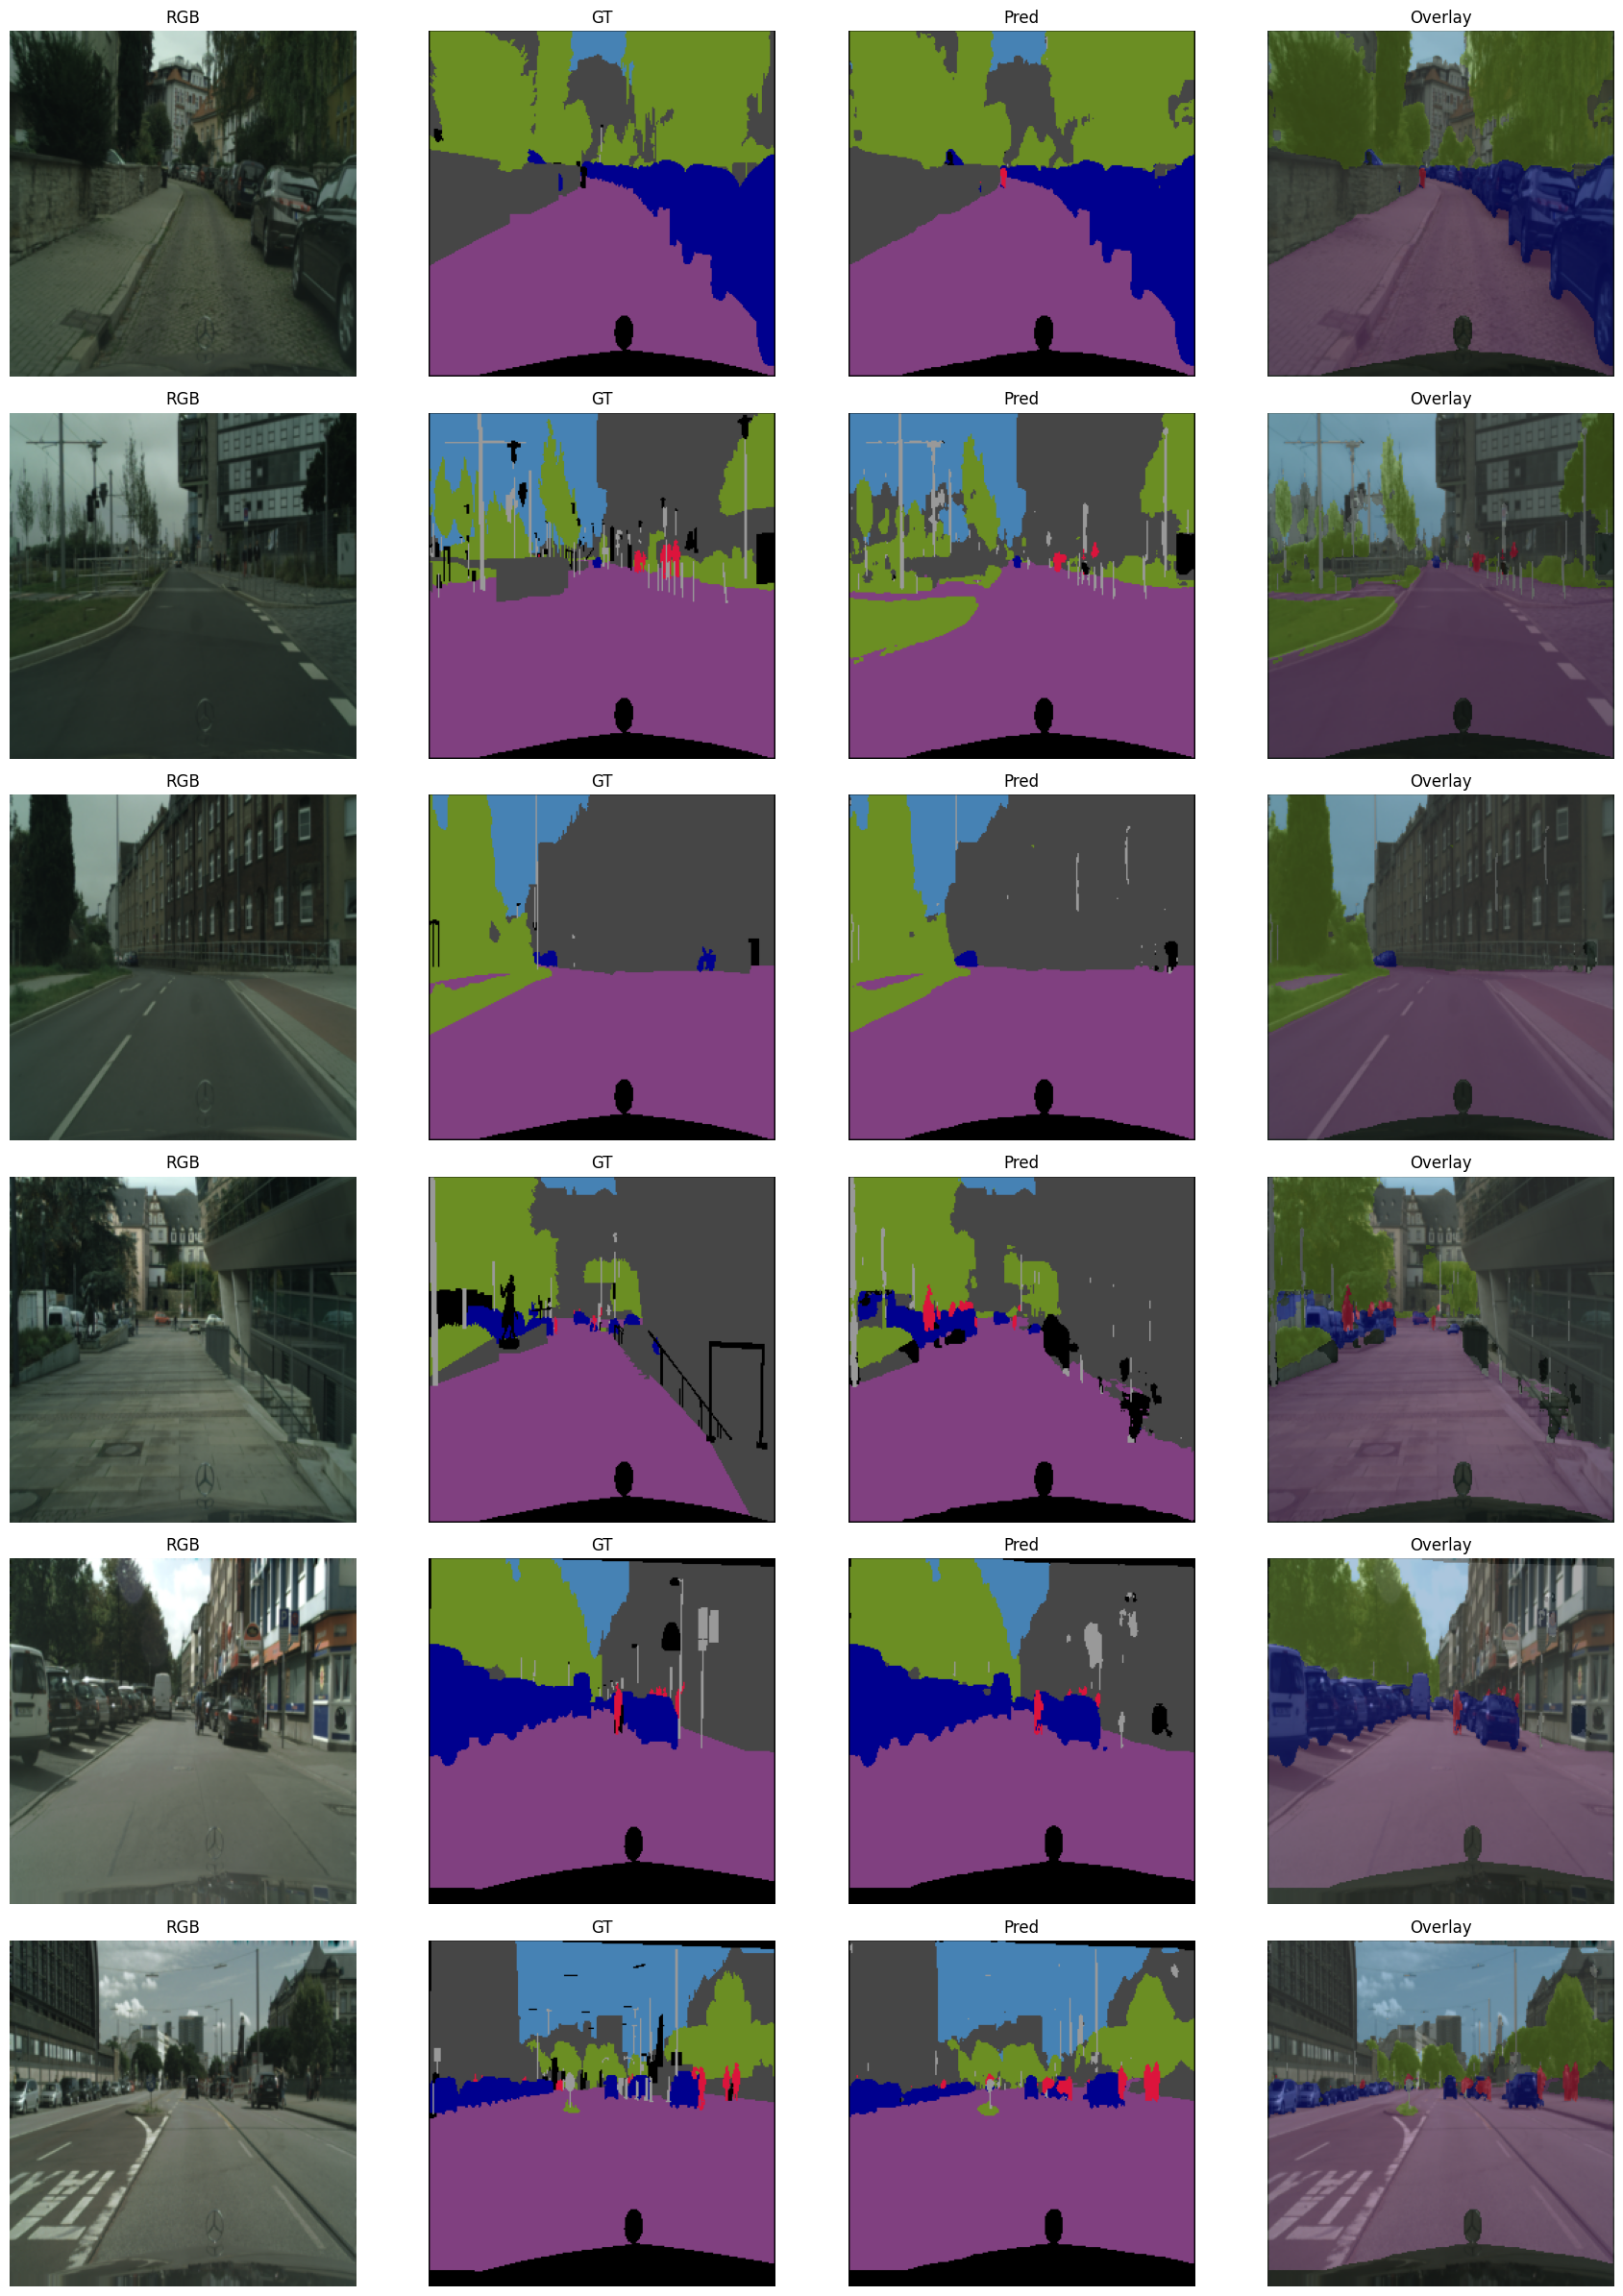

In [10]:
res_vgg_frozen = run_vgg16(trainable=False, epochs=40)
res_vgg_ft = run_vgg16(trainable=True, epochs=30, patience=6)